# SIGAP AI - Analysis Sentiment Model Building


### Import Library

In [2]:
# Common
import os
import re
import time
import pandas as pd

# Model
from sklearn.model_selection import train_test_split

# Preprocessing
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter


### Path Configuration


In [3]:
# KONFIGURASI PATH
BASE_DIR   = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "dataset")

DIPAWIDIA_PATH = os.path.join(DATA_DIR, "dipawidia_reviews.csv")
GMAPS_PATH = os.path.join(DATA_DIR, "gmaps_reviews.csv")
PRDECT_PATH = os.path.join(DATA_DIR, "prdect-id_reviews.csv")


In [4]:
# Tambahan path dataset F&B
RESTAURANT_10000_PATH = os.path.join(DATA_DIR, "10000restaurant_reviews.csv")
ABSA_RESTAURANT_PATH = os.path.join(DATA_DIR, "absaRestaurant_reviews.csv")
GMAPS_RESTAURANT2_PATH = os.path.join(DATA_DIR, "gmaps_reviews2.csv")
GMAPS_KAGGLE_PATH = os.path.join(DATA_DIR, "gmaps-kaggle_reviews.csv")
MENDELEY_CUSTOMER_PATH = os.path.join(DATA_DIR, "mendeley-customer_reviews.csv")

NDJEDIR_PATH = os.path.join(DATA_DIR, "Ndjedir_reviews.csv")
UMAYUMCHA_PATH = os.path.join(DATA_DIR, "umayumcha_reviews.csv")
BITTERSWEET_PATH = os.path.join(DATA_DIR, "cp-bittersweet_reviews.csv")
FORE_COFFEE_PATH = os.path.join(DATA_DIR, "fore-coffe_reviews.csv")

# Path tambahan dataset Google Play Review F&B
GOFOOD_GOOGLEPLAY_PATH = os.path.join(DATA_DIR, "gofood_googleplay_reviews.csv")
GRABFOOD_GOOGLEPLAY_PATH = os.path.join(DATA_DIR, "grabfood_googleplay_reviews.csv")

# Path tambahan dataset Netral F&B terbaru
TOKOPEDIA_PRODUCT_PATH = os.path.join(DATA_DIR, "tokopedia_product_reviews.csv")
BURGERKING_PATH = os.path.join(DATA_DIR, "burgerking_reviews.csv")
GOFOOD_NETRAL_PATH = os.path.join(DATA_DIR, "gofood_netral_googleplay_reviews.csv")
GRABFOOD_NETRAL_PATH = os.path.join(DATA_DIR, "grabfood_netral_googleplay_reviews.csv")
DOMINOS_NETRAL_PATH = os.path.join(DATA_DIR, "dominos_netral_googleplay_reviews.csv")
PIZZAHUT_NETRAL_PATH = os.path.join(DATA_DIR, "pizzahut_netral_googleplay_reviews.csv")
KOPIKENANGAN_NETRAL_PATH = os.path.join(DATA_DIR, "kopikenangan_netral_googleplay_reviews.csv")
STARBUCKS_NETRAL_PATH = os.path.join(DATA_DIR, "starbucks_netral_googleplay_reviews.csv")
KFCKU_NETRAL_PATH = os.path.join(DATA_DIR, "kfcku_netral_googleplay_reviews.csv")
ASTRO_NETRAL_PATH = os.path.join(DATA_DIR, "astro_netral_googleplay_reviews.csv")
SEGARI_NETRAL_PATH = os.path.join(DATA_DIR, "segari_netral_googleplay_reviews.csv")
MIE_GACOAN_GENTENG_PATH = os.path.join(DATA_DIR, "mie_gacoan_genteng_reviews.csv")


### Basic Cleaning + Merge Dataset


In [5]:
# Basic Function

EMPTY_LIKE = {"", "null", "nan", "none"}

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    if text.lower() in EMPTY_LIKE:
        return ""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def extract_rating(value):
    value = str(value).strip()
    if re.fullmatch(r'[1-5](\.0)?', value):
        return int(float(value))
    return pd.NA

def clean_reviews_date(value):
    value = clean_text(value)
    return value if value else "unknown"


def first_non_empty(*values):
    for value in values:
        cleaned = clean_text(value)
        if cleaned:
            return cleaned
    return ""

def build_googlemaps_text(row):
    return first_non_empty(row.get("text", ""), row.get("textTranslated", ""))


In [6]:
STANDARD_COLUMNS = [
    "Review_Text",
    "Review_Date",
    "Rating_Score",
    "Business_Category",
    "Dataset_Source",
    "Raw_Sentiment",
    "Raw_Category",
    "Raw_Id",
]


In [7]:
# Dipawidia 
def loadset_dipawidia():
    df_raw = pd.read_csv(DIPAWIDIA_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": pd.NA,
        "Business_Category": "Lainnya",
        "Dataset_Source": "Dipawidia",
        "Raw_Sentiment": df_raw["sentimen"].fillna(""),
        "Raw_Category": "",
        "Raw_Id": df_raw.index.astype(str),
    })

    return df[STANDARD_COLUMNS]

# Google Maps
def loadset_googlemaps():
    df_raw = pd.read_csv(GMAPS_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    raw_id = df_raw["reviewId"].replace("", pd.NA)
    fallback_id = pd.Series(df_raw.index.astype(str), index=df_raw.index)
    raw_id = raw_id.combine_first(fallback_id)

    df = pd.DataFrame({
        "Review_Text": df_raw.apply(build_googlemaps_text, axis=1),
        "Review_Date": df_raw["publishedAtDate"].apply(clean_reviews_date),
        "Rating_Score": df_raw["stars"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoogleMaps",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["title"].fillna(""),
        "Raw_Id": raw_id.astype(str),
    })

    return df[STANDARD_COLUMNS]

# Prdect-ID
def loadset_prdect():
    df_raw = pd.read_csv(PRDECT_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Customer Review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": df_raw["Customer Rating"].apply(extract_rating),
        "Business_Category": df_raw["Category"].fillna(""),
        "Dataset_Source": "PRDECT-ID",
        "Raw_Sentiment": df_raw["Sentiment"].fillna(""),
        "Raw_Category": df_raw["Category"].fillna(""),
        "Raw_Id": df_raw.index.astype(str),
    })

    return df[STANDARD_COLUMNS]


# load dataset Tokopedia kategori Food and Drink
def loadset_tokopedia_product():
    df_raw = pd.read_csv(TOKOPEDIA_PRODUCT_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Tokopedia Food and Drink",
        "Raw_Sentiment": "",
        "Raw_Category": "Food and Drink",
        "Raw_Id": "tokopedia_food_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Burger King Indonesia
def loadset_burgerking():
    df_raw = pd.read_csv(BURGERKING_PATH, dtype=str, encoding="latin-1").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Review"].apply(clean_text),
        "Review_Date": df_raw["Date"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Burger King Indonesia",
        "Raw_Sentiment": "",
        "Raw_Category": "Burger King Indonesia",
        "Raw_Id": "burgerking_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# helper loader untuk dataset netral Google Play F&B yang memiliki struktur kolom sama
def loadset_googleplay_netral(path, dataset_source, raw_id_prefix):
    df_raw = pd.read_csv(path, dtype=str, encoding="utf-8-sig").fillna("")

    raw_id = df_raw["review_id"].replace("", pd.NA)
    fallback_id = raw_id_prefix + df_raw.index.astype(str)
    raw_id = raw_id.combine_first(pd.Series(fallback_id, index=df_raw.index))

    df = pd.DataFrame({
        "Review_Text": df_raw["review_text"].apply(clean_text),
        "Review_Date": df_raw["review_date"].apply(clean_reviews_date),
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": dataset_source,
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["matched_keywords"].fillna(""),
        "Raw_Id": raw_id.astype(str)})

    return df[STANDARD_COLUMNS]


# load dataset netral Google Play GoFood dan GrabFood
def loadset_gofood_netral():
    return loadset_googleplay_netral(GOFOOD_NETRAL_PATH, "GoFood GooglePlay", "gofood_netral_")


def loadset_grabfood_netral():
    return loadset_googleplay_netral(GRABFOOD_NETRAL_PATH, "GrabFood GooglePlay", "grabfood_netral_")


# load dataset netral Google Play dari aplikasi resmi F&B Indonesia
def loadset_dominos_netral():
    return loadset_googleplay_netral(DOMINOS_NETRAL_PATH, "Dominos Netral GooglePlay", "dominos_netral_")


def loadset_pizzahut_netral():
    return loadset_googleplay_netral(PIZZAHUT_NETRAL_PATH, "Pizza Hut Netral GooglePlay", "pizzahut_netral_")


def loadset_kopikenangan_netral():
    return loadset_googleplay_netral(KOPIKENANGAN_NETRAL_PATH, "Kopi Kenangan Netral GooglePlay", "kopikenangan_netral_")


def loadset_starbucks_netral():
    return loadset_googleplay_netral(STARBUCKS_NETRAL_PATH, "Starbucks Netral GooglePlay", "starbucks_netral_")


# load tambahan dataset netral Google Play KFCKU, ASTRO, dan Segari
def loadset_kfcku_netral():
    return loadset_googleplay_netral(KFCKU_NETRAL_PATH, "KFCKU Netral GooglePlay", "kfcku_netral_")


def loadset_astro_netral():
    return loadset_googleplay_netral(ASTRO_NETRAL_PATH, "ASTRO Netral GooglePlay", "astro_netral_")


def loadset_segari_netral():
    return loadset_googleplay_netral(SEGARI_NETRAL_PATH, "Segari Netral GooglePlay", "segari_netral_")


# load dataset review Gofood mie gacoan genteng
def loadset_mie_gacoan_genteng():
    df_raw = pd.read_csv(MIE_GACOAN_GENTENG_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review"].apply(clean_text),
        "Review_Date": df_raw["tanggal_pesan"].apply(clean_reviews_date),
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Mie Gacoan Genteng",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["pesanan"].fillna(""),
        "Raw_Id": "mie_gacoan_genteng_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


In [8]:
df_dipawidia = loadset_dipawidia()
df_googlemaps = loadset_googlemaps()
df_prdect = loadset_prdect()

df_all = pd.concat([df_dipawidia, df_googlemaps, df_prdect], ignore_index=True)


In [9]:
# Dataset baru dengan fokus F&B

def translate_restaurant_review(text):
    text = clean_text(text)
    if not text:
        return ""
    phrase_map = {
        "good food" : "makanan enak", "great food": "makanan sangat enak", "excellent food": "makanan sangat enak", "bad food": "makanan kurang enak",
        "tasty": "enak", "delicious": "enak", "ambience": "suasana", "service": "pelayanan", "staff": "staf", "waiter": "pelayan", "place": "tempat",
        "restaurant": "restoran", "recommended": "direkomendasikan", "must try": "wajib dicoba", "cost effective": "harga sepadan", "expensive": "mahal",
        "cheap": "murah", "friendly": "ramah", "courteous": "sopan", "helpful": "membantu", "prompt": "cepat", "slow": "lambat", "pleasant": "nyaman",
        "good experience": "pengalaman baik", "bad experience": "pengalaman buruk", "quality": "kualitas", "taste": "rasa", "flavor": "rasa",
        "menu": "menu", "portion": "porsi", "price": "harga", "worth": "sepadan", "affordable": "terjangkau", "food prices": "harga makanan",
        "vegetable dishes": "menu sayur", "meat dishes": "menu daging", "dessert": "makanan penutup", "breakfast": "sarapan", "dinner": "makan malam",
        "lunch": "makan siang", "cashier": "kasir", "clean": "bersih", "not clean": "kurang bersih", "queue": "antrean", "wait": "menunggu",
        "annoying": "mengganggu"}

    translated = text.lower()
    translated = re.sub(r"http\S+|www\S+", " ", translated)
    for src, dst in phrase_map.items():
        translated = re.sub(rf"\b{re.escape(src)}\b", dst, translated)
    translated = re.sub(r"\s+", " ", translated).strip()
    return translated


def sentiment_from_text(text):
    text = normalize_text(text) if 'normalize_text' in globals() else clean_text(text).lower()

    positive_words = [
        'enak', 'lezat', 'mantap', 'bagus', 'baik', 'ramah', 'nyaman', 'puas', 'recommended', 'rekomendasi'                                                                                                                                                                                                                            ,
        'murah', 'cepat', 'bersih', 'suka', 'fresh', 'good', 'great', 'excellent', 'tasty', 'delicious', 'love', 'best']
    negative_words = [
        'tidak enak', 'kurang enak', 'buruk', 'kecewa', 'mahal', 'lambat', 'kotor', 'keras', 'hambar',
        'asin', 'pahit', 'lama', 'bad', 'worst', 'disappointed', 'expensive', 'slow', 'dirty', 'poor']

    positive_score = sum(1 for word in positive_words if word in text)
    negative_score = sum(1 for word in negative_words if word in text)

    if positive_score > negative_score:
        return 'Positive'
    if negative_score > positive_score:
        return 'Negative'
    return 'Netral'


def sentiment_to_fallback_rating(sentiment):
    sentiment = normalize_label(sentiment) if 'normalize_label' in globals() else clean_text(sentiment)
    if sentiment == 'Positive':
        return 5
    if sentiment == 'Negative':
        return 2
    if sentiment == 'Netral':
        return 3
    return pd.NA


def reconstruct_absa_sentences(df_raw):
    df_raw = df_raw.copy().fillna("")
    df_raw["Kalimat #"] = df_raw["Kalimat #"].astype(str)
    df_raw["Word"] = df_raw["Word"].apply(clean_text)
    df_raw = df_raw[df_raw["Word"].ne("")].copy()

    sentence_df = (
        df_raw
        .groupby("Kalimat #", sort=False)
        .agg({
            "Word": lambda words: " ".join(words),
            "Tag": lambda tags: ", ".join(sorted(set(clean_text(tag) for tag in tags if clean_text(tag) and clean_text(tag) != "O")))})
        .reset_index()
        .rename(columns={"Word": "Review_Text", "Tag": "Raw_Category"}))

    sentence_df["Review_Text"] = sentence_df["Review_Text"].apply(clean_text)
    return sentence_df


def gmaps2_clean_review(text):
    text = clean_text(text)
    text = text.replace('?', ' ')
    text = re.sub(r'\blainnya\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# helper untuk mengecek csv satu kolom yang ada koma di teks review
def read_single_review_csv(path, text_col="Review"):
    rows = []
    with open(path, "r", encoding="utf-8-sig", errors="replace") as file:
        lines = file.read().splitlines()

    for idx, line in enumerate(lines):
        if idx == 0 and clean_text(line).lower() == text_col.lower():
            continue
        review = clean_text(line)
        if review:
            rows.append(review)

    return pd.DataFrame({text_col: rows})


# helper untuk membaca export X/twitter dataset fore coffee yang quote/delimiternya tidak standar
def read_fore_twitter_csv(path):
    import csv

    parsed_rows = []
    with open(path, "r", encoding="utf-8-sig", errors="replace") as file:
        for raw_line in file.read().splitlines():
            line = raw_line.rstrip(";").strip()
            if line.startswith('"') and line.endswith('"'):
                line = line[1:-1]
            line = line.replace('""', '"')
            try:
                parsed_rows.append(next(csv.reader([line])))
            except Exception:
                continue

    if not parsed_rows:
        return pd.DataFrame(columns=["created_at", "full_text", "id_str"])

    header = parsed_rows[0]
    rows = [row for row in parsed_rows[1:] if len(row) == len(header)]
    return pd.DataFrame(rows, columns=header)


# helper filter agar ulasan dari fore coffe yang masuk tetap relevan dengan f&b
def is_fore_food_related(text):
    text = normalize_text(text) if 'normalize_text' in globals() else clean_text(text).lower()
    include_keywords = [
        'fore', 'coffee', 'kopi', 'matcha', 'latte', 'americano', 'espresso', 'minum', 'minuman',
        'cup', 'gelas', 'menu', 'rasa', 'enak', 'pesen', 'beli', 'promo', 'diskon', 'aplikasi fore']
    exclude_keywords = [
        'witir', 'tahajud', 'sholat', 'hbd', 'baseanak', 'anakfk', 'kuliah', 'skripsi', 'tugas',
        'ujian', 'kampus', 'drakor', 'anime', 'game', 'politik', 'pemilu', 'loker', 'lowongan',
        'giveaway', 'mutualan']

    if any(keyword in text for keyword in exclude_keywords):
        return False
    return any(keyword in text for keyword in include_keywords)


In [10]:
# Load dataset F&B

def loadset_restaurant_10000():
    df_raw = pd.read_csv(RESTAURANT_10000_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Review"].apply(translate_restaurant_review),
        "Review_Date": df_raw["Time"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "10000Restaurant",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["Restaurant"].fillna(""),
        "Raw_Id": df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_absa_restaurant():
    df_raw = pd.read_csv(ABSA_RESTAURANT_PATH, dtype=str, encoding="utf-8-sig").fillna("")
    df_sentences = reconstruct_absa_sentences(df_raw)
    raw_sentiment = df_sentences["Review_Text"].apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": df_sentences["Review_Text"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "ABSA Restaurant",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": df_sentences["Raw_Category"].fillna(""),
        "Raw_Id": df_sentences["Kalimat #"].astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_gmaps_restaurant2():
    df_raw = pd.read_csv(GMAPS_RESTAURANT2_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    review_text = df_raw["ulsn"].apply(gmaps2_clean_review)
    raw_sentiment = review_text.apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": review_text,
        "Review_Date": df_raw["rsqaWe"].apply(clean_reviews_date),
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoogleMaps2",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": df_raw["d4r55"].fillna(""),
        "Raw_Id": "gmaps2_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_gmaps_kaggle():
    df_raw = pd.read_csv(GMAPS_KAGGLE_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["text"].apply(translate_restaurant_review),
        "Review_Date": "unknown",
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoogleMaps Kaggle",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["rating_category"].fillna(""),
        "Raw_Id": "gmaps_kaggle_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


def loadset_mendeley_customer():
    df_raw = pd.read_csv(MENDELEY_CUSTOMER_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Teks_Ulasan"].apply(clean_text),
        "Review_Date": df_raw["Tanggal_Ulasan"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Mendeley Customer",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["Nama_UMKM"].fillna(""),
        "Raw_Id": "mendeley_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Ndjedir dari csv hasil konversi asal xlsx
def loadset_ndjedir():
    df_raw = pd.read_csv(NDJEDIR_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Review_Ulasan"].apply(clean_text),
        "Review_Date": df_raw["Waktu"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Ndjedir",
        "Raw_Sentiment": "",
        "Raw_Category": "Seblak Ndjedir",
        "Raw_Id": "ndjedir_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset UmaYumcha dari csv hasil konversi asal xlsx
def loadset_umayumcha():
    df_raw = pd.read_csv(UMAYUMCHA_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["Teks_Ulasan"].apply(clean_text),
        "Review_Date": df_raw["Waktuu"].apply(clean_reviews_date),
        "Rating_Score": df_raw["Rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Umayumcha",
        "Raw_Sentiment": "",
        "Raw_Category": "Uma Yumcha",
        "Raw_Id": "umayumcha_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Bittersweet, rating menggunakan fallback dari teks karena file hanya berisi review
def loadset_bittersweet():
    df_raw = read_single_review_csv(BITTERSWEET_PATH, text_col="Review")
    raw_sentiment = df_raw["Review"].apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": df_raw["Review"].apply(clean_text),
        "Review_Date": "unknown",
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Bittersweet",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": "Bittersweet by Najla",
        "Raw_Id": "bittersweet_" + df_raw.index.astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Forecoffee dari X/Twitter yang difilter agar tetap relevan dengan F&B
def loadset_fore_coffee():
    df_raw = read_fore_twitter_csv(FORE_COFFEE_PATH).fillna("")
    df_raw = df_raw[df_raw["full_text"].apply(is_fore_food_related)].copy()
    raw_sentiment = df_raw["full_text"].apply(sentiment_from_text)

    df = pd.DataFrame({
        "Review_Text": df_raw["full_text"].apply(clean_text),
        "Review_Date": df_raw["created_at"].apply(clean_reviews_date),
        "Rating_Score": raw_sentiment.apply(sentiment_to_fallback_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "Fore Coffee",
        "Raw_Sentiment": raw_sentiment,
        "Raw_Category": "Fore Coffee",
        "Raw_Id": "fore_" + df_raw["id_str"].astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Google play review GoFood
def loadset_gofood_googleplay():
    df_raw = pd.read_csv(GOFOOD_GOOGLEPLAY_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review_text"].apply(clean_text),
        "Review_Date": df_raw["review_date"].apply(clean_reviews_date),
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GoFood GooglePlay",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["matched_keywords"].fillna(""),
        "Raw_Id": df_raw["review_id"].replace("", pd.NA).combine_first(pd.Series(df_raw.index.astype(str), index=df_raw.index)).astype(str)})

    return df[STANDARD_COLUMNS]


# Load dataset Google play review GrabFood
def loadset_grabfood_googleplay():
    df_raw = pd.read_csv(GRABFOOD_GOOGLEPLAY_PATH, dtype=str, encoding="utf-8-sig").fillna("")

    df = pd.DataFrame({
        "Review_Text": df_raw["review_text"].apply(clean_text),
        "Review_Date": df_raw["review_date"].apply(clean_reviews_date),
        "Rating_Score": df_raw["rating"].apply(extract_rating),
        "Business_Category": "F&B",
        "Dataset_Source": "GrabFood GooglePlay",
        "Raw_Sentiment": "",
        "Raw_Category": df_raw["matched_keywords"].fillna(""),
        "Raw_Id": df_raw["review_id"].replace("", pd.NA).combine_first(pd.Series(df_raw.index.astype(str), index=df_raw.index)).astype(str)})

    return df[STANDARD_COLUMNS]


In [11]:
# menggabungkan dataset F&B baru ke dataset utama
df_restaurant_10000 = loadset_restaurant_10000()
df_absa_restaurant = loadset_absa_restaurant()
df_googlemaps2 = loadset_gmaps_restaurant2()
df_gmaps_kaggle = loadset_gmaps_kaggle()
df_mendeley_customer = loadset_mendeley_customer()
df_ndjedir = loadset_ndjedir()
df_umayumcha = loadset_umayumcha()
df_bittersweet = loadset_bittersweet()
df_fore_coffee = loadset_fore_coffee()
df_gofood_googleplay = loadset_gofood_googleplay()
df_grabfood_googleplay = loadset_grabfood_googleplay()

# Load tambahan dataset Netral F&B terbaru
df_tokopedia_product = loadset_tokopedia_product()
df_burgerking = loadset_burgerking()
df_gofood_netral = loadset_gofood_netral()
df_grabfood_netral = loadset_grabfood_netral()
df_dominos_netral = loadset_dominos_netral()
df_pizzahut_netral = loadset_pizzahut_netral()
df_kopikenangan_netral = loadset_kopikenangan_netral()
df_starbucks_netral = loadset_starbucks_netral()
df_kfcku_netral = loadset_kfcku_netral()
df_astro_netral = loadset_astro_netral()
df_segari_netral = loadset_segari_netral()
df_mie_gacoan_genteng = loadset_mie_gacoan_genteng()

print("Dataset F&B baru:")
print(f"  10000Restaurant     : {len(df_restaurant_10000):,} baris")
print(f"  ABSA Restaurant     : {len(df_absa_restaurant):,} baris")
print(f"  GoogleMaps2         : {len(df_googlemaps2):,} baris")
print(f"  GoogleMaps Kaggle   : {len(df_gmaps_kaggle):,} baris")
print(f"  Mendeley Customer   : {len(df_mendeley_customer):,} baris")
print(f"  Ndjedir             : {len(df_ndjedir):,} baris")
print(f"  Umayumcha           : {len(df_umayumcha):,} baris")
print(f"  Bittersweet         : {len(df_bittersweet):,} baris")
print(f"  Fore Coffee         : {len(df_fore_coffee):,} baris")
print(f"  GoFood GooglePlay   : {len(df_gofood_googleplay):,} baris")
print(f"  GrabFood GooglePlay : {len(df_grabfood_googleplay):,} baris")
print(f"  Tokopedia F&B       : {len(df_tokopedia_product):,} baris")
print(f"  Burger King         : {len(df_burgerking):,} baris")
print(f"  GoFood Netral      : {len(df_gofood_netral):,} baris")
print(f"  GrabFood Netral    : {len(df_grabfood_netral):,} baris")
print(f"  Dominos Netral     : {len(df_dominos_netral):,} baris")
print(f"  Pizza Hut Netral   : {len(df_pizzahut_netral):,} baris")
print(f"  Kopi Kenangan       : {len(df_kopikenangan_netral):,} baris")
print(f"  Starbucks Netral   : {len(df_starbucks_netral):,} baris")
print(f"  KFCKU Netral       : {len(df_kfcku_netral):,} baris")
print(f"  ASTRO Netral       : {len(df_astro_netral):,} baris")
print(f"  Segari Netral      : {len(df_segari_netral):,} baris")
print(f"  Mie Gacoan Genteng  : {len(df_mie_gacoan_genteng):,} baris")

before_added = len(df_all)
df_all = pd.concat([
    df_all,
    df_restaurant_10000,
    df_absa_restaurant,
    df_googlemaps2,
    df_gmaps_kaggle,
    df_mendeley_customer,
    df_ndjedir,
    df_umayumcha,
    df_bittersweet,
    df_fore_coffee,
    df_gofood_googleplay,
    df_grabfood_googleplay,
    df_tokopedia_product,
    df_burgerking,
    df_gofood_netral,
    df_grabfood_netral,
    df_dominos_netral,
    df_pizzahut_netral,
    df_kopikenangan_netral,
    df_starbucks_netral,
    df_kfcku_netral,
    df_astro_netral,
    df_segari_netral,
    df_mie_gacoan_genteng], ignore_index=True)

print(f"Total sebelum menambahkan : {before_added:,} baris")
print(f"Total setelah menambahkan : {len(df_all):,} baris")


Dataset F&B baru:
  10000Restaurant     : 10,000 baris
  ABSA Restaurant     : 860 baris
  GoogleMaps2         : 566 baris
  GoogleMaps Kaggle   : 1,100 baris
  Mendeley Customer   : 100 baris
  Ndjedir             : 194 baris
  Umayumcha           : 108 baris
  Bittersweet         : 1,363 baris
  Fore Coffee         : 880 baris
  GoFood GooglePlay   : 1,438 baris
  GrabFood GooglePlay : 1,256 baris
  Tokopedia F&B       : 5,428 baris
  Burger King         : 1,067 baris
  GoFood Netral      : 615 baris
  GrabFood Netral    : 357 baris
  Dominos Netral     : 612 baris
  Pizza Hut Netral   : 703 baris
  Kopi Kenangan       : 173 baris
  Starbucks Netral   : 117 baris
  KFCKU Netral       : 178 baris
  ASTRO Netral       : 12 baris
  Segari Netral      : 14 baris
  Mie Gacoan Genteng  : 2,418 baris
Total sebelum menambahkan : 27,870 baris
Total setelah menambahkan : 57,429 baris


In [12]:

source_summary = df_all["Dataset_Source"].value_counts()
category_summary = df_all["Business_Category"].value_counts()

print("Distribusi dataset setelah menambahkan F&B:")
print(source_summary)

print("\nDistribusi kategori bisnis setelah menambahkan F&B:")
print(category_summary)


Distribusi dataset setelah menambahkan F&B:
Dataset_Source
Dipawidia                          11606
GoogleMaps                         10864
10000Restaurant                    10000
Tokopedia Food and Drink            5428
PRDECT-ID                           5400
Mie Gacoan Genteng                  2418
GoFood GooglePlay                   2053
GrabFood GooglePlay                 1613
Bittersweet                         1363
GoogleMaps Kaggle                   1100
Burger King Indonesia               1067
Fore Coffee                          880
ABSA Restaurant                      860
Pizza Hut Netral GooglePlay          703
Dominos Netral GooglePlay            612
GoogleMaps2                          566
Ndjedir                              194
KFCKU Netral GooglePlay              178
Kopi Kenangan Netral GooglePlay      173
Starbucks Netral GooglePlay          117
Umayumcha                            108
Mendeley Customer                    100
Segari Netral GooglePlay              1

In [13]:

# Cleaning awal setelah semua dataset berhasil digabung
# Tujuannya agar noise yang kosong/pendek tidak ikut masuk ke proses labeling dan split
before_basic_clean = len(df_all)

missing_text_before = int(df_all["Review_Text"].astype(str).str.strip().eq("").sum())

df_all["Review_Text"] = df_all["Review_Text"].apply(clean_text)
df_all = df_all[df_all["Review_Text"].ne("")].copy()

df_all = df_all[df_all["Review_Text"].str.split().str.len().fillna(0).ge(2)].copy()

before_duplicate_clean = len(df_all)
df_all = df_all.drop_duplicates(
    keep="first").reset_index(drop=True)

duplicate_removed = before_duplicate_clean - len(df_all)
basic_noise = before_basic_clean - len(df_all)
basic_noise_pct = round((basic_noise / before_basic_clean) * 100, 2) if before_basic_clean else 0

print(f"Total sebelum cleaning awal      : {before_basic_clean:,} baris")
print(f"Total setelah cleaning awal      : {len(df_all):,} baris")
print(f"Review kosong yang terdeteksi    : {missing_text_before:,} baris")
print(f"Duplikat terhapus                : {duplicate_removed:,} baris")
print(f"Noise awal terfilter             : {basic_noise:,} baris ({basic_noise_pct}%)")


Total sebelum cleaning awal      : 57,429 baris
Total setelah cleaning awal      : 50,983 baris
Review kosong yang terdeteksi    : 4,057 baris
Duplikat terhapus                : 213 baris
Noise awal terfilter             : 6,446 baris (11.22%)


### Data Exploration & Visualization

#### Exploration

In [14]:
print("Jumlah Data:", len(df_all))
print("\nKolom Dataset:")
print(df_all.columns.tolist())

display(df_all.head())

Jumlah Data: 50983

Kolom Dataset:
['Review_Text', 'Review_Date', 'Rating_Score', 'Business_Category', 'Dataset_Source', 'Raw_Sentiment', 'Raw_Category', 'Raw_Id']


,Review_Text,Review_Date,Rating_Score,Business_Category,Dataset_Source,Raw_Sentiment,Raw_Category,Raw_Id
0,Suara dan mic puas. Hanya saya pesan yg nyala ...,unknown,<NA>,Lainnya,Dipawidia,0,,0
1,Good. Mudah-mudahan awet. Makasih,unknown,<NA>,Lainnya,Dipawidia,1,,1
2,"kondisi dus robek2, tolong di perhatikan lagi",unknown,<NA>,Lainnya,Dipawidia,0,,2
3,Kualitas produk baik. Harga terjangkau dan pen...,unknown,<NA>,Lainnya,Dipawidia,0,,3
4,"Overall bagus, tombol berfungsi semuanya, tapi...",unknown,<NA>,Lainnya,Dipawidia,0,,4


In [15]:
df_all.shape

(50983, 8)

In [16]:
df_all.describe()

,Review_Text,Review_Date,Rating_Score,Business_Category,Dataset_Source,Raw_Sentiment,Raw_Category,Raw_Id
count,50983,50983,39340,50983,50983,50983,50983,50983
unique,49828,23923,5,31,24,6,2802,35450
top,very good,unknown,5,F&B,Dipawidia,,,47
freq,28,24676,19350,34149,11498,30573,13285,4


In [17]:
df_all.dtypes

Review_Text          object
Review_Date          object
Rating_Score         object
Business_Category    object
Dataset_Source       object
Raw_Sentiment        object
Raw_Category         object
Raw_Id               object
dtype: object

In [18]:
df_all.isnull().sum()

Review_Text              0
Review_Date              0
Rating_Score         11643
Business_Category        0
Dataset_Source           0
Raw_Sentiment            0
Raw_Category             0
Raw_Id                   0
dtype: int64

#### Visualization

In [19]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

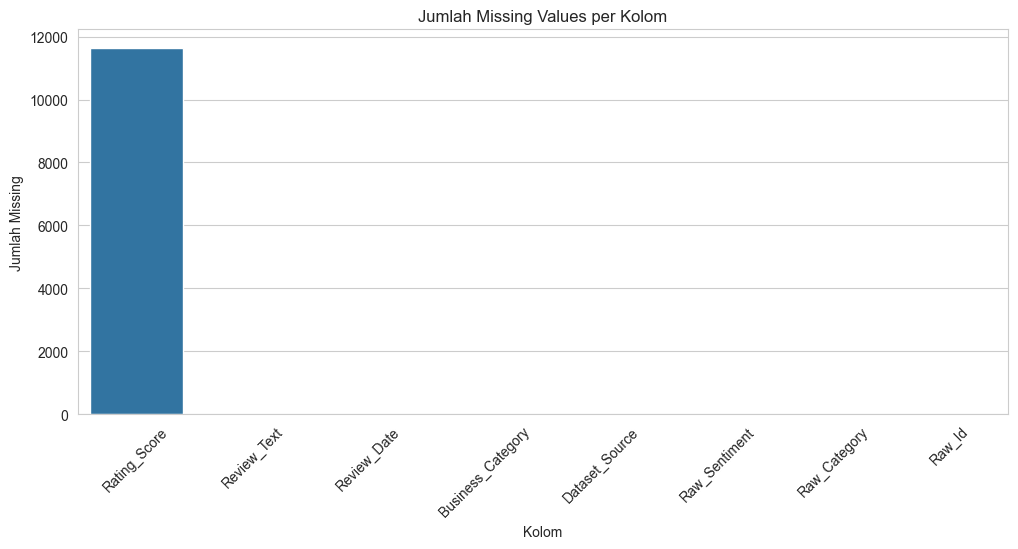

In [20]:
missing_values = df_all.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Jumlah Missing Values per Kolom")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Missing")
plt.xlabel("Kolom")
plt.show()

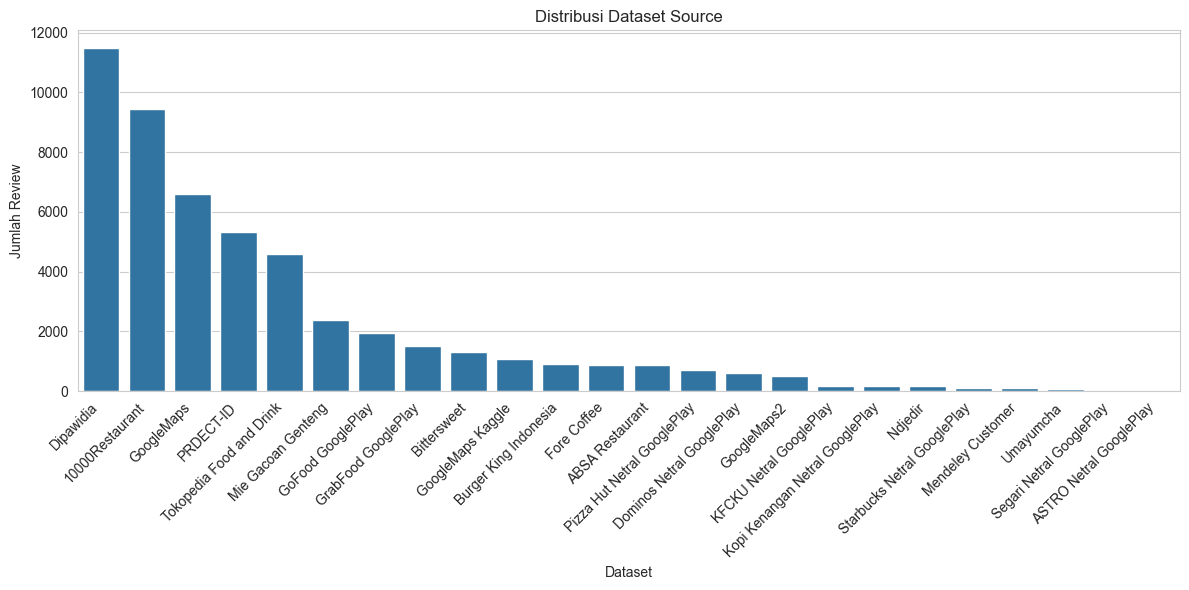

In [21]:
source_counts = df_all["Dataset_Source"].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(
    x=source_counts.index,
    y=source_counts.values
)

plt.title("Distribusi Dataset Source")
plt.xlabel("Dataset")
plt.ylabel("Jumlah Review")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

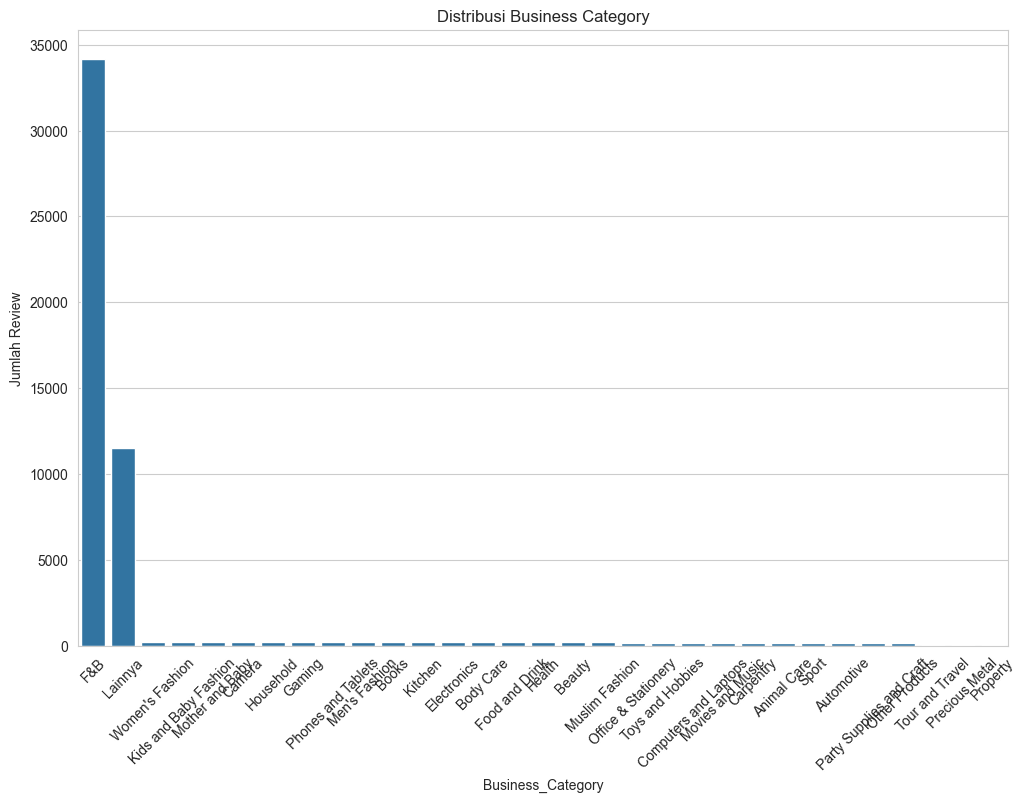

In [22]:
category_counts = df_all["Business_Category"].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values
)

plt.title("Distribusi Business Category")
plt.xticks(rotation=45)
plt.ylabel("Jumlah Review")
plt.show()

In [23]:
rating_df = df_all.dropna(subset=["Rating_Score"]).copy()
rating_df["Rating_Score"] = rating_df["Rating_Score"].astype(int)

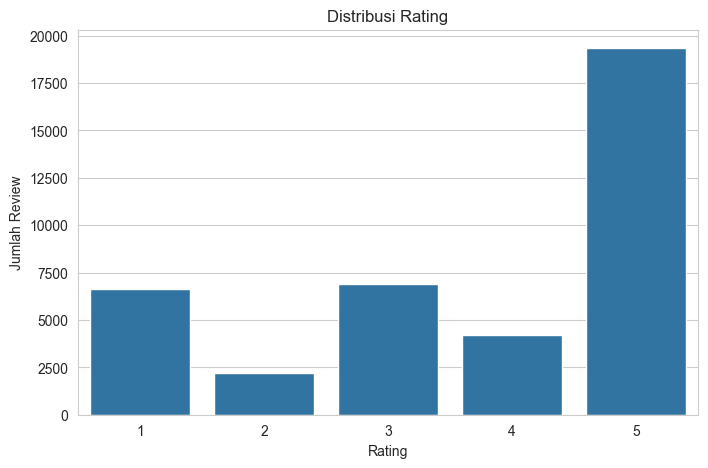

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Rating_Score",
    data=rating_df
)

plt.title("Distribusi Rating")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()

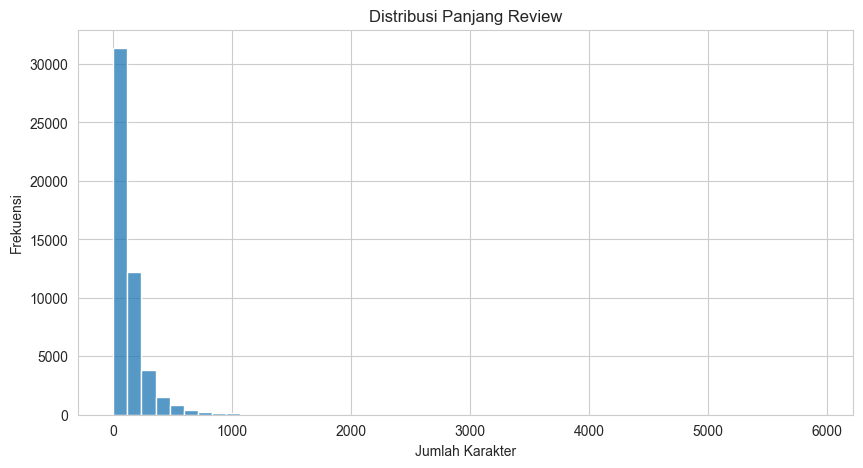

In [25]:
df_all["Review_Length"] = df_all["Review_Text"].str.len()

plt.figure(figsize=(10, 5))

sns.histplot(
    df_all["Review_Length"],
    bins=50
)

plt.title("Distribusi Panjang Review")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")
plt.show()

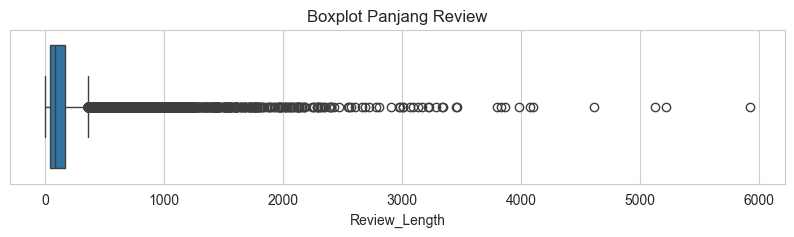

In [26]:
plt.figure(figsize=(10, 2))

sns.boxplot(
    x=df_all["Review_Length"]
)

plt.title("Boxplot Panjang Review")
plt.show()

In [27]:
duplicate_count = df_all.duplicated(subset=["Review_Text"]).sum()

print(f"Jumlah Duplicate Review: {duplicate_count}")
print(f"Persentase Duplicate: {(duplicate_count / len(df_all)) * 100:.2f}%")

Jumlah Duplicate Review: 1155
Persentase Duplicate: 2.27%


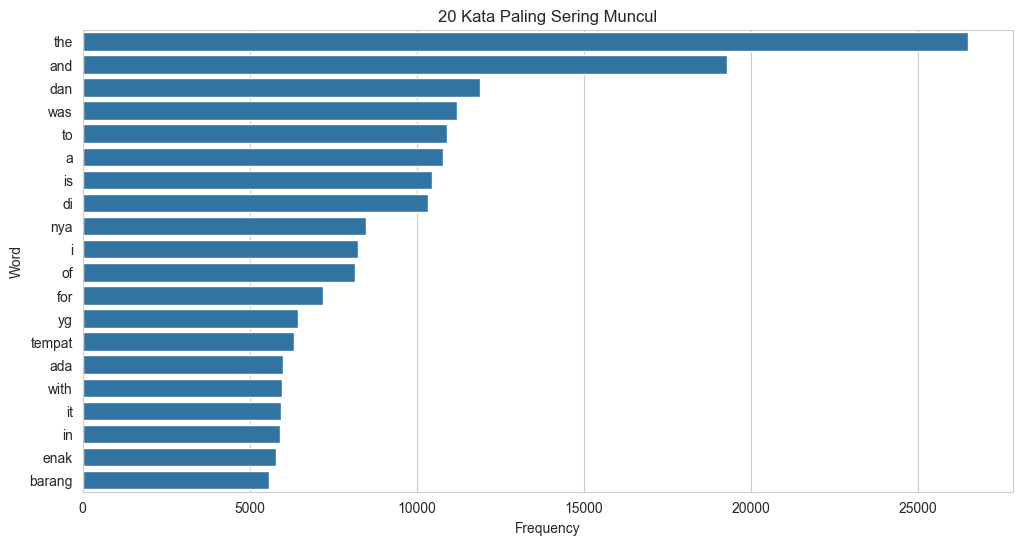

In [28]:
all_text = " ".join(df_all["Review_Text"].astype(str)).lower()

words = all_text.split()

word_freq = Counter(words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=["Word", "Frequency"]
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("20 Kata Paling Sering Muncul")
plt.show()

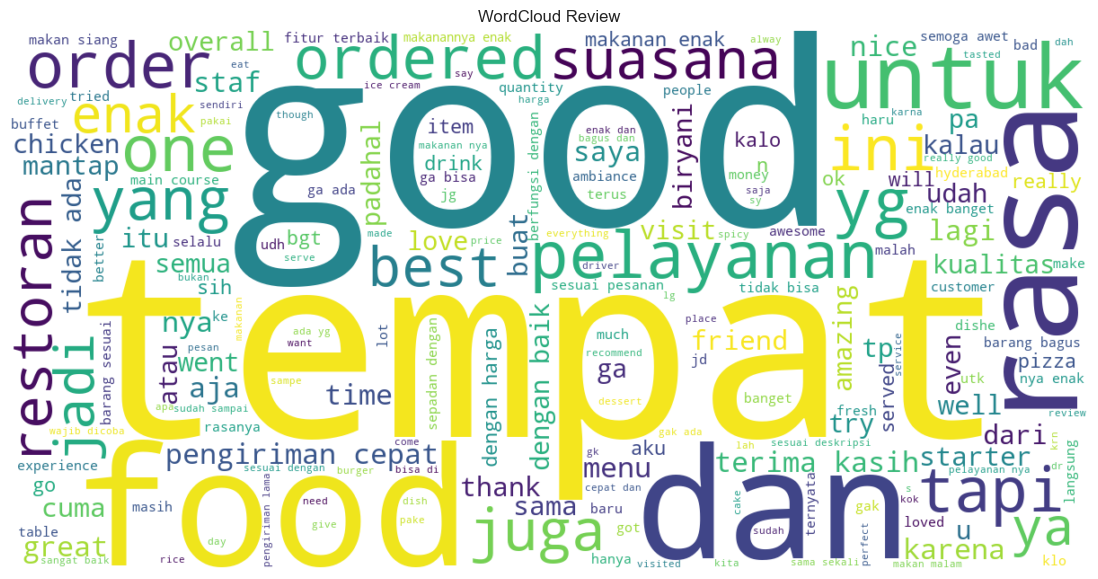

In [29]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Review")
plt.show()

In [30]:
df_all[[
    "Review_Text",
    "Dataset_Source",
    "Rating_Score"
]].sample(10)

,Review_Text,Dataset_Source,Rating_Score
1328,"Barang realpict, pengirimanya cepat, kurirnya ...",Dipawidia,<NA>
29276,"cool tempat to hang out, food is good. thanks ...",10000Restaurant,5
48102,Gabisa menjangkau daerah rumah saya 😂 bete,Pizza Hut Netral GooglePlay,3
8935,Alhamdulillah selamat sampai tujuan tanpa kendala,Dipawidia,<NA>
18046,Sebulan sekali wajib kesini. Buat fangshen. Da...,GoogleMaps,5
15433,"nyaman dan enak, ramah sekali #Irma",GoogleMaps,5
2939,Fitur Terbaik:empuk Sepadan dengan Harga:yes S...,Dipawidia,<NA>
32114,visited the tempat at midnight the best thing ...,10000Restaurant,4
48242,"Cmn kasih 3 karena , udah 2x beli rencana awal...",Kopi Kenangan Netral GooglePlay,3
15080,Ini enak beneran. Steak nya empuk dan enak ban...,GoogleMaps,5


### Labeling

In [31]:
keyword_netral = [
    'lumayan', 'biasa saja', 'biasa aja', 'cukup', 'standar', 'oke lah', 'okelah',
    'tidak buruk', 'tidak terlalu', 'bisa lah', 'bisalah', 'plus minus', 'sesuai harga',
    'masih oke', 'masih bisa', 'masih lumayan', 'belum tahu', 'belum tau']

keyword_rasa = [
    'rasa', 'enak', 'lezat', 'gurih', 'manis', 'asin', 'pahit', 'asam', 'nikmat', 'sedap',
    'hambar', 'segar', 'mantap', 'yummy', 'flavor', 'taste', 'bumbu', 'aroma', 'wangi',
    'harum', 'bau', 'pedas', 'crispy', 'renyah', 'tekstur', 'empuk', 'keras', 'lembut',
    'makanan', 'minuman', 'kopi', 'snack', 'matang', 'gosong', 'dingin', 'hangat', 'fresh',
    'juicy', 'creamy', 'aftertaste', 'porsi']

keyword_harga = [
    'harga', 'murah', 'mahal', 'worth', 'worthit', 'worth it', 'terjangkau', 'ekonomis',
    'hemat', 'diskon', 'promo', 'cashback', 'ongkir', 'gratis', 'sesuai harga',
    'overpriced', 'kemahalan', 'budget', 'biaya', 'bayar', 'tagihan', 'nominal', 'rupiah',
    'sebanding', 'tidak sebanding', 'mahal banget', 'murah meriah']

keyword_bentuk = [
    'bentuk', 'ukuran', 'kemasan', 'packaging', 'tampilan', 'desain', 'warna', 'model',
    'penampilan', 'fisik', 'material', 'bahan', 'kualitas', 'kokoh', 'kuat', 'rapuh',
    'tahan lama', 'awet', 'nyaman', 'pas', 'layar', 'body', 'casing', 'jahitan',
    'original', 'ori', 'asli', 'palsu', 'sesuai gambar', 'sesuai deskripsi', 'bagus',
    'jelek', 'rapi', 'bersih', 'kotor', 'besar', 'kecil', 'tipis', 'tebal', 'berat', 'ringan',
    'halus', 'kasar', 'lecet', 'penyok', 'retak', 'robek', 'pecah']

keyword_krisis = [
    'penipuan', 'tipu', 'bohong', 'palsu', 'rusak', 'cacat', 'hancur', 'kecewa',
    'tidak sesuai', 'tidak sama', 'berbeda', 'salah kirim', 'tidak sampai', 'hilang',
    'komplain', 'refund', 'return', 'retur', 'tidak berfungsi', 'tidak nyala', 'mati',
    'error', 'gagal', 'mengecewakan', 'parah', 'buruk', 'jangan beli', 'hindari',
    'barang tidak datang', 'barang hilang', 'pesanan tidak sesuai', 'uang tidak kembali',
    'tidak ori', 'lama banget', 'seller tidak merespon', 'pelayanan buruk', 'expired']

keyword_negasi = [
    'tidak', 'tak', 'bukan', 'belum', 'kurang', 'tanpa', 'gak', 'ga', 'nggak', 'ngga',
    'tdk', 'tp', 'tapi', 'namun', 'sayangnya', 'sayang']

keyword_sarcasm_positif = [
    'mantap', 'keren', 'jos', 'josss', 'perfect', 'sempurna', 'luar biasa', 'terbaik',
    'worth it', 'worthit', 'memuaskan', 'berkualitas', 'bintang lima', '5 bintang',
    'recommended banget', 'bagus banget', 'mantap banget', 'puas banget']

category_mapping_dataset_prdect = {
    'Food and Drink': 'F&B', 'Kitchen': 'F&B',
    'Computers and Laptops': 'Elektronik', 'Phones and Tablets': 'Elektronik',
    'Electronics': 'Elektronik', 'Camera': 'Elektronik', 'Gaming': 'Elektronik',
    "Women's Fashion": 'Fashion', "Men's Fashion": 'Fashion', 'Muslim Fashion': 'Fashion',
    'Kids and Baby Fashion': 'Fashion',
    'Health': 'Kesehatan & Kecantikan', 'Beauty': 'Kesehatan & Kecantikan',
    'Body Care': 'Kesehatan & Kecantikan',
    'Household': 'Perabotan', 'Carpentry': 'Perabotan',
    'Mother and Baby': 'Ibu & Bayi',
    'Animal Care': 'Perawatan Hewan',
    'Toys and Hobbies': 'Hobi & Hiburan', 'Movies and Music': 'Hobi & Hiburan',
    'Books': 'Hobi & Hiburan', 'Tour and Travel': 'Hobi & Hiburan', 'Sport': 'Hobi & Hiburan',
    'Automotive': 'Otomotif',
    'Office & Stationery': 'Perlengkapan Kantor',
    'Party Supplies and Craft': 'Kerajinan & Pesta',
    'Precious Metal': 'Lainnya', 'Property': 'Lainnya', 'Other Products': 'Lainnya'}


In [32]:
# Labeling data
LABELS = {'Positive', 'Negative', 'Netral'}

RAW_SENTIMENT_MAP = {
    '0': 'Negative',
    '1': 'Positive',
    'positive': 'Positive',
    'positif': 'Positive',
    'negative': 'Negative',
    'negatif': 'Negative',
    'neutral': 'Netral',
    'netral': 'Netral',
}

def normalize_text(text):
    if not isinstance(text, str):
        return ''
    text = clean_text(text)
    return text.lower()


def contains_any(text, keywords):
    text = normalize_text(text)
    for kw in keywords:
        kw = normalize_text(kw)
        if kw and kw in text:
            return True
    return False


def to_int_rating(value):
    if pd.isna(value):
        return None
    try:
        return int(float(str(value).strip()))
    except Exception:
        return None


def normalize_label(label):
    label = normalize_text(label)
    return RAW_SENTIMENT_MAP.get(label, '')


def rating_to_sentiment(rating):
    if rating is None:
        return ''
    if rating in [1, 2]:
        return 'Negative'
    if rating == 3:
        return 'Netral'
    if rating in [4, 5]:
        return 'Positive'
    return ''


def assign_sentiment(row):
    source = clean_text(row.get('Dataset_Source', ''))
    text = normalize_text(row.get('Review_Text', ''))
    raw_sentiment = normalize_label(row.get('Raw_Sentiment', ''))
    rating = to_int_rating(row.get('Rating_Score', None))

    if source == 'Dipawidia':
        if raw_sentiment in LABELS:
            return raw_sentiment
        if contains_any(text, keyword_netral):
            return 'Netral'
        sentiment_from_rating = rating_to_sentiment(rating)
        if sentiment_from_rating:
            return sentiment_from_rating
        return 'Netral'

    sentiment_from_rating = rating_to_sentiment(rating)
    if sentiment_from_rating:
        return sentiment_from_rating

    if raw_sentiment in LABELS:
        return raw_sentiment

    return 'Netral'


def assign_rating(row):
    rating = to_int_rating(row.get('Rating_Score', None))
    if rating is not None:
        return rating

    sentiment = normalize_label(row.get('Sentiment_Label', ''))
    if sentiment == 'Negative':
        return 2
    if sentiment == 'Netral':
        return 3
    if sentiment == 'Positive':
        return 5

    return pd.NA


def detect_aspect(text):
    if not isinstance(text, str):
        return 'Lainnya'

    text_lower = normalize_text(text)

    scores = {
        'Rasa': sum(1 for kw in keyword_rasa if normalize_text(kw) in text_lower),
        'Harga': sum(1 for kw in keyword_harga if normalize_text(kw) in text_lower),
        'Bentuk': sum(1 for kw in keyword_bentuk if normalize_text(kw) in text_lower),
    }

    max_score = max(scores.values())

    if max_score == 0:
        return 'Lainnya'

    for aspect in ['Rasa', 'Harga', 'Bentuk']:
        if scores[aspect] == max_score:
            return aspect

    return 'Lainnya'


def assign_crisis(row):
    sentiment = normalize_label(row.get('Sentiment_Label', ''))
    rating = to_int_rating(row.get('Rating_Score', None))
    text = normalize_text(row.get('Review_Text', ''))

    is_negative = sentiment == 'Negative'
    is_low_rating = rating is not None and rating <= 2

    if (is_negative or is_low_rating) and contains_any(text, keyword_krisis):
        return 'Yes'
    return 'No'


def assign_business_category(row):
    source = clean_text(row.get('Dataset_Source', ''))
    raw_category = clean_text(row.get('Raw_Category', ''))
    current_category = clean_text(row.get('Business_Category', ''))

    if source == 'PRDECT-ID':
        return category_mapping_dataset_prdect.get(raw_category, 'Lainnya')

    return current_category if current_category else 'Lainnya'


def assign_sarcasm(row):
    if normalize_label(row.get('Sentiment_Label', '')) != 'Negative':
        return 'No'

    text = normalize_text(row.get('Review_Text', ''))
    if not text:
        return 'No'

    for keyword in keyword_sarcasm_positif:
        kw = normalize_text(keyword)
        if kw and kw in text:
            idx = text.find(kw)
            context_before = text[max(0, idx - 25):idx]
            if contains_any(context_before, keyword_negasi):
                return 'No'
            return 'Yes'

    return 'No'

In [33]:
def labeling_dataset(df):
    df = df.copy()

    required_cols = [
        "Review_Text",
        "Rating_Score",
        "Dataset_Source",
        "Business_Category",
        "Raw_Category",
        "Raw_Sentiment",
    ]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")
    
    if "Rating_Score_Original" not in df.columns:
        df["Rating_Score_Original"] = df["Rating_Score"]

    df["Sentiment_Label"] = df.apply(assign_sentiment, axis=1)

    df["Rating_Score"] = df.apply(assign_rating, axis=1)

    df["Review_Aspect"] = df["Review_Text"].apply(detect_aspect)

    df["Crisis_Flag"] = df.apply(assign_crisis, axis=1)

    df["Business_Category"] = df.apply(assign_business_category, axis=1)

    df["Is_Sarcasm"] = df.apply(assign_sarcasm, axis=1)

    return df

In [34]:
df_all_labeled = labeling_dataset(df_all)

print("\nSentiment distribution / Distribusi sentimen:")
sentiment_counts = df_all_labeled["Sentiment_Label"].value_counts(dropna=False)
for label, count in sentiment_counts.items():
    pct = (count / len(df_all_labeled)) * 100
    print(f"  {label:<10} : {count:>8,} ({pct:.1f}%)")


Sentiment distribution / Distribusi sentimen:
  Positive   :   29,288 (57.4%)
  Negative   :   14,629 (28.7%)
  Netral     :    7,066 (13.9%)


In [35]:
# Melakukan balancing sentimen agar data seimbang dan diambil dari data yang terkecil
RANDOM_STATE = 42

sentiment_counts_before = df_all_labeled["Sentiment_Label"].value_counts()
min_label_count = sentiment_counts_before.min()

before_balancing = len(df_all_labeled)

balanced_parts = []

for label in sentiment_counts_before.index:
    label_data = df_all_labeled[df_all_labeled["Sentiment_Label"].eq(label)]
    balanced_parts.append(
        label_data.sample(
            n=min_label_count,
            random_state=RANDOM_STATE))

df_all_labeled = (
    pd.concat(balanced_parts, ignore_index=True)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True))

after_balancing = len(df_all_labeled)
removed_balancing = before_balancing - after_balancing

print("Distribusi sentimen sebelum balancing:")
print(sentiment_counts_before)

print("\nDistribusi sentimen setelah balancing:")
print(df_all_labeled["Sentiment_Label"].value_counts())

print(f"\nTotal sebelum balancing sentimen : {before_balancing:,} baris")
print(f"Total setelah balancing sentimen   : {after_balancing:,} baris")
print(f"Data yang dikurangi                : {removed_balancing:,} baris")

Distribusi sentimen sebelum balancing:
Sentiment_Label
Positive    29288
Negative    14629
Netral       7066
Name: count, dtype: int64

Distribusi sentimen setelah balancing:
Sentiment_Label
Negative    7066
Netral      7066
Positive    7066
Name: count, dtype: int64

Total sebelum balancing sentimen : 50,983 baris
Total setelah balancing sentimen   : 21,198 baris
Data yang dikurangi                : 29,785 baris


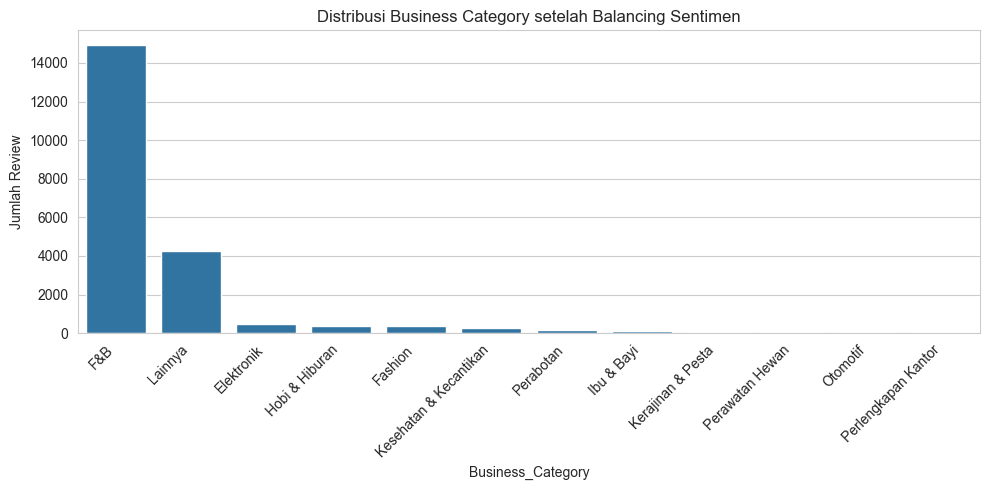

In [36]:
category_counts = df_all_labeled["Business_Category"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values)

plt.title("Distribusi Business Category setelah Balancing Sentimen")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Jumlah Review")
plt.xlabel("Business_Category")
plt.tight_layout()
plt.show()


### Data Splitting



In [37]:
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

df_train_val, df_test = train_test_split(
    df_all_labeled,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_all_labeled["Sentiment_Label"]
)

validation_ratio = VALIDATION_SIZE / (TRAIN_SIZE + VALIDATION_SIZE)

df_train, df_validation = train_test_split(
    df_train_val,
    test_size=validation_ratio,
    random_state=RANDOM_STATE,
    stratify=df_train_val["Sentiment_Label"]
)

df_train = df_train.reset_index(drop=True)
df_validation = df_validation.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(f"Data train      : {len(df_train):,} baris")
print(f"Data validation : {len(df_validation):,} baris")
print(f"Data test       : {len(df_test):,} baris")

print("\nDistribusi sentimen train:")
print(df_train["Sentiment_Label"].value_counts())

print("\nDistribusi sentimen validation:")
print(df_validation["Sentiment_Label"].value_counts())

print("\nDistribusi sentimen test:")
print(df_test["Sentiment_Label"].value_counts())


Data train      : 14,838 baris
Data validation : 3,180 baris
Data test       : 3,180 baris

Distribusi sentimen train:
Sentiment_Label
Positive    4946
Netral      4946
Negative    4946
Name: count, dtype: int64

Distribusi sentimen validation:
Sentiment_Label
Positive    1060
Netral      1060
Negative    1060
Name: count, dtype: int64

Distribusi sentimen test:
Sentiment_Label
Positive    1060
Negative    1060
Netral      1060
Name: count, dtype: int64


### Data Preprocessing

In [38]:
def cleaning_dataset(df):
    df = df.copy()
    info = {}

    info["total_awal_raw"] = len(df)
    before_cols = df.columns.tolist()

    # Normalisasi teks 
    df["Review_Text"] = df["Review_Text"].apply(clean_text)

    # Hapus review kosong
    mask_text_empty = df["Review_Text"].eq("")
    info["teks_kosong"] = int(mask_text_empty.sum())
    df = df.loc[~mask_text_empty].copy()

    # Data Rating Dipawidia dikeep
    mask_rating_valid = df["Rating_Score"].notna() | df["Dataset_Source"].eq("Dipawidia")
    info["hapus_rating"] = int((~mask_rating_valid).sum())
    df = df.loc[mask_rating_valid].copy()

    # Standardisasi tipe data rating
    if "Rating_Score" in df.columns:
        df["Rating_Score"] = pd.to_numeric(df["Rating_Score"], errors="coerce").astype("Int64")

    # Hapus duplikasi
    dup_subset = ["Review_Text", "Review_Date", "Rating_Score", "Dataset_Source"]
    before_dup = len(df)
    df = df.drop_duplicates(subset=dup_subset).copy()
    info["hapus_duplikat"] = before_dup - len(df)

    # Hapus review yang terlalu pendek
    before_short = len(df)
    mask_long_enough = df["Review_Text"].str.split().str.len().fillna(0).ge(2)
    df = df.loc[mask_long_enough].copy()
    info["hapus_pendek"] = before_short - len(df)

    df = df.reset_index(drop=True)

    info["total_akhir"] = len(df)
    info["total_noise"] = info["total_awal_raw"] - info["total_akhir"]
    info["noise_pct"] = round((info["total_noise"] / info["total_awal_raw"]) * 100, 2) if info["total_awal_raw"] else 100

    after_cols = df.columns.tolist()
    info["kolom_awal"] = before_cols
    info["kolom_akhir"] = after_cols
    info["kolom_baru"] = [c for c in after_cols if c not in before_cols]
    info["kolom_hilang"] = [c for c in before_cols if c not in after_cols]

    return df, info


In [39]:
slang_dict = {
    "yg": "yang", "dg": "dengan", "dgn": "dengan", "utk": "untuk",
    "tdk": "tidak", "gak": "tidak", "ga": "tidak", "nggak": "tidak",
    "ngga": "tidak", "gk": "tidak", "bgt": "banget", "bgtt": "banget",
    "tp": "tapi", "tpi": "tapi", "krn": "karena", "karna": "karena",
    "aja": "saja", "jg": "juga", "jd": "jadi", "sdh": "sudah",
    "udh": "sudah", "blm": "belum", "msh": "masih", "mksh": "terima kasih",
    "makasih": "terima kasih", "thanks": "terima kasih", "thx": "terima kasih",
    "recomend": "recommended", "rekomen": "recommended", "ori": "original",
    "mantap": "bagus", "keren": "bagus", "jos": "bagus"
}

preserve_terms = {
    "original", "palsu", "garansi", "refund", "return", "komplain",
    "diskon", "promo", "cashback", "ongkir", "packaging", "seller",
    "rating", "review", "baterai", "charger", "wifi", "bluetooth",
    "android", "gaming", "premium", "fashion", "enak", "lezat",
    "gurih", "renyah", "crispy", "manis", "pahit", "asam",
    "pedas", "asin", "empuk", "keras", "lembut", "murah",
    "mahal", "hemat", "cepat", "lambat", "rusak", "bagus",
    "buruk", "jelek", "puas", "kecewa", "hancur", "cacat",
    "tipu", "hilang", "error", "gagal"
}

custom_stopwords = {
    "wah", "wow", "hehe", "haha", "hihi", "dong", "nih", "sih", "deh", "lah",
    "ini", "itu", "sini", "sana", "saya", "aku", "kami", "kita", "mereka", "anda",
    "hari", "minggu", "bulan", "tahun", "jam", "menit", "kemarin", "sekarang", "nanti",
    "order", "pesan", "beli", "produk", "barang", "item", "paket", "dapat", "terima",
    "datang", "tiba", "sampai", "kirim", "dikirim", "foto", "gambar", "deskripsi"
}

important_negations = {"tidak", "tak", "bukan", "belum", "jangan", "gak", "ga", "nggak", "ngga", "tdk"}

factory_stop = StopWordRemoverFactory()
sastrawi_stop = set(factory_stop.get_stop_words())

all_stopwords = (sastrawi_stop | custom_stopwords) - important_negations

factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()


In [40]:
stem_cache = {}

def stem_cached(word):
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)
    return stem_cache[word]

def preprocess_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""

    URL_PATTERN = re.compile(r"http\S+|www\S+|https\S+")
    NON_ALNUM_PATTERN = re.compile(r"[^a-z0-9\s]")
    MULTISPACE_PATTERN = re.compile(r"\s+")
    NUMBER_PATTERN = re.compile(r"\b\d+\b")

    # Lowercase + hapus URL
    text = text.lower()
    text = URL_PATTERN.sub(" ", text)

    # Pertahankan huruf, angka, spasi
    text = NON_ALNUM_PATTERN.sub(" ", text)
    text = NUMBER_PATTERN.sub(" ", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()

    tokens = text.split()

    # Slang normalization
    tokens = [slang_dict.get(tok, tok) for tok in tokens]

    cleaned_tokens = []
    for tok in tokens:
        if tok in all_stopwords:
            continue
        if len(tok) <= 1:
            continue

        # Simpan istilah penting
        if tok in preserve_terms:
            cleaned_tokens.append(tok)
        else:
            cleaned_tokens.append(stem_cached(tok))

    return re.sub(r"\s+", " ", " ".join(cleaned_tokens)).strip()


def preprocessing_dataset(df):
    df = df.copy()
    before_cols = df.columns.tolist()

    df["Review_Text_Processed"] = df["Review_Text"].apply(preprocess_text)

    # Hapus hasil proses yang kosong
    mask_non_empty = df["Review_Text_Processed"].astype(str).str.strip().ne("")
    removed_empty = int((~mask_non_empty).sum())
    df = df.loc[mask_non_empty].copy()

    df = df.reset_index(drop=True)

    after_cols = df.columns.tolist()
    col_info = {
        "kolom_awal": before_cols,
        "kolom_akhir": after_cols,
        "kolom_baru": [c for c in after_cols if c not in before_cols],
        "kolom_hilang": [c for c in before_cols if c not in after_cols],
    }

    return df, removed_empty, col_info


def print_column_change(info, title=""):
    if title:
        print(f"\n{title}")
    print(f"    Kolom awal   : {len(info['kolom_awal'])}")
    print(f"    Kolom akhir  : {len(info['kolom_akhir'])}")
    print(f"    Kolom baru   : {info['kolom_baru']}")
    print(f"    Kolom hilang : {info['kolom_hilang']}")

In [41]:
df_train_clean, info_clean_train = cleaning_dataset(df_train)
df_validation_clean, info_clean_validation = cleaning_dataset(df_validation)
df_test_clean, info_clean_test = cleaning_dataset(df_test)

print(f"    Train setelah cleaning      : {len(df_train_clean):,} baris")
print(f"    Validation setelah cleaning : {len(df_validation_clean):,} baris")
print(f"    Test setelah cleaning       : {len(df_test_clean):,} baris")
print(f"    Noise train                 : {info_clean_train['noise_pct']}%")
print(f"    Noise validation            : {info_clean_validation['noise_pct']}%")
print(f"    Noise test                  : {info_clean_test['noise_pct']}%")

print_column_change(info_clean_train, title="[Train] Perubahan struktur kolom setelah cleaning")
print_column_change(info_clean_validation, title="[Validation] Perubahan struktur kolom setelah cleaning")
print_column_change(info_clean_test, title="[Test] Perubahan struktur kolom setelah cleaning")

start_time = time.time()

df_train_final, empty_train, col_info_train = preprocessing_dataset(df_train_clean)
df_validation_final, empty_validation, col_info_validation = preprocessing_dataset(df_validation_clean)
df_test_final, empty_test, col_info_test = preprocessing_dataset(df_test_clean)

elapsed = round(time.time() - start_time, 2)

print(f"    Train final                  : {len(df_train_final):,} baris")
print(f"    Validation final             : {len(df_validation_final):,} baris")
print(f"    Test final                   : {len(df_test_final):,} baris")
print(f"    Baris kosong setelah proses  : {empty_train + empty_validation + empty_test:,}")
print(f"    Waktu proses preprocessing   : {elapsed} detik")

print_column_change(col_info_train, title="[Train] Perubahan struktur kolom setelah preprocessing")
print_column_change(col_info_validation, title="[Validation] Perubahan struktur kolom setelah preprocessing")
print_column_change(col_info_test, title="[Test] Perubahan struktur kolom setelah preprocessing")


    Train setelah cleaning      : 14,815 baris
    Validation setelah cleaning : 3,180 baris
    Test setelah cleaning       : 3,179 baris
    Noise train                 : 0.16%
    Noise validation            : 0.0%
    Noise test                  : 0.03%

[Train] Perubahan struktur kolom setelah cleaning
    Kolom awal   : 14
    Kolom akhir  : 14
    Kolom baru   : []
    Kolom hilang : []

[Validation] Perubahan struktur kolom setelah cleaning
    Kolom awal   : 14
    Kolom akhir  : 14
    Kolom baru   : []
    Kolom hilang : []

[Test] Perubahan struktur kolom setelah cleaning
    Kolom awal   : 14
    Kolom akhir  : 14
    Kolom baru   : []
    Kolom hilang : []
    Train final                  : 14,777 baris
    Validation final             : 3,172 baris
    Test final                   : 3,172 baris
    Baris kosong setelah proses  : 53
    Waktu proses preprocessing   : 4.84 detik

[Train] Perubahan struktur kolom setelah preprocessing
    Kolom awal   : 14
    Kolom akhir  

In [42]:
FINAL_COLUMNS = [
    "Review_Text",
    "Review_Text_Processed",
    "Review_Date",
    "Rating_Score",
    "Business_Category",
    "Sentiment_Label",
    "Review_Aspect",
    "Crisis_Flag",
    "Is_Sarcasm"
]


In [43]:
df_train_final = df_train_final[FINAL_COLUMNS].copy()
df_validation_final = df_validation_final[FINAL_COLUMNS].copy()
df_test_final = df_test_final[FINAL_COLUMNS].copy()

print("\nDATASET TRAIN")
display(df_train_final.head())

print("\nDATASET VALIDATION")
display(df_validation_final.head())

print("\nDATASET TEST")
display(df_test_final.head())



DATASET TRAIN


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,if you're looking out for the perfect punjabi ...,if you re looking out for the perfect punjabi ...,9/9/2018 13:40,5,F&B,Positive,Lainnya,No,No
1,Rasanya biasa aja untuk nasi kebuli dan cender...,nasi kebuli cenderung minyak nasi putih kasih ...,unknown,3,F&B,Netral,Rasa,No,No
2,Gak JELAS. LAMA MAHAL GAK ENAK...!!!!,tidak mahal tidak,2026-01-07T06:29:22.918Z,1,F&B,Negative,Rasa,No,No
3,"Kardus sedikit rusak, pengiriman terjeda sehar...",kardus rusak kirim jeda hari jual ngasih infor...,unknown,2,Lainnya,Negative,Bentuk,Yes,No
4,tergiur karna liat review di google aku nunggu...,giur liat review google nunggu tempat penuh ba...,unknown,5,F&B,Positive,Rasa,No,No



DATASET VALIDATION


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,packing rapi,packing rapi,unknown,5,F&B,Positive,Bentuk,No,No
1,pastikan alat makannya sekali lagi ya,pasti alat makan,Ordered on 30 December 2022,3,F&B,Netral,Bentuk,No,No
2,tidak sesuai yg dharapkan .. berharap yg datan...,tidak sesuai dharapkan harap merek maspion nya...,unknown,2,Lainnya,Negative,Bentuk,Yes,No
3,Mantap pelayanan oke makanan oke,bagus layan oke makan oke,2026-02-19T13:30:47.623Z,5,F&B,Positive,Rasa,No,No
4,the bar ambiance is good. we ordered chilli br...,the bar ambiance is good we ordered chilli bro...,10/20/2018 7:29,2,F&B,Negative,Rasa,Yes,No



DATASET TEST


,Review_Text,Review_Text_Processed,Review_Date,Rating_Score,Business_Category,Sentiment_Label,Review_Aspect,Crisis_Flag,Is_Sarcasm
0,udah pasti enak sihh,udah sihh,unknown,5,F&B,Positive,Rasa,No,No
1,paneer was not good.,paneer was not good,5/1/2018 0:19,2,F&B,Negative,Lainnya,No,No
2,"i ordered cappuccino and got black coffee, rea...",ordered cappuccino and got black coffee read o...,4/8/2018 23:49,1,F&B,Negative,Lainnya,No,No
3,"Barang sesuai, tersegel hologram..",sesuai segel hologram,unknown,5,Lainnya,Positive,Lainnya,No,No
4,"the best tempat for chinese lover, the food is...",the best for chinese lover the food is very au...,1/13/2019 10:56,4,F&B,Positive,Lainnya,No,No


In [44]:
# validasi kpi
final_combined = pd.concat([df_train_final, df_validation_final, df_test_final], ignore_index=True)

important_fields = [
    "Review_Text",
    "Review_Text_Processed",
    "Rating_Score",
    "Business_Category",
    "Sentiment_Label",
    "Review_Aspect",
]

missing_important = final_combined[important_fields].isna().sum().sum()
empty_important = final_combined[important_fields].astype(str).apply(lambda col: col.str.strip().eq("")).sum().sum()
total_important = len(final_combined) * len(important_fields)
completeness_pct = round(((total_important - missing_important - empty_important) / total_important) * 100, 2)

noise_total_awal = info_clean_train["total_awal_raw"] + info_clean_validation["total_awal_raw"] + info_clean_test["total_awal_raw"]
noise_total = info_clean_train["total_noise"] + info_clean_validation["total_noise"] + info_clean_test["total_noise"]
noise_pct = round((noise_total / noise_total_awal) * 100, 2) if noise_total_awal else 100

rating_sentiment_check = final_combined.copy()
rating_sentiment_check["Rating_Score"] = pd.to_numeric(rating_sentiment_check["Rating_Score"], errors="coerce")
rating_sentiment_check["Sentiment_From_Rating"] = rating_sentiment_check["Rating_Score"].apply(lambda rating: rating_to_sentiment(int(rating)) if pd.notna(rating) else "")
valid_check = rating_sentiment_check["Sentiment_From_Rating"].ne("")
label_agreement_pct = round((rating_sentiment_check.loc[valid_check, "Sentiment_Label"] == rating_sentiment_check.loc[valid_check, "Sentiment_From_Rating"]).mean() * 100, 2) if valid_check.any() else 0

kpi_result = pd.DataFrame({
    "KPI": [
        "Tingkat Noise data setelah Cleaning",
        "Konsisten Labeling",
        "Kelengkapan Dataset field penting",
    ],
    "Target": ["< 10%", ">= 85%", ">= 95%"],
    "Hasil": [f"{noise_pct}%", f"{label_agreement_pct}%", f"{completeness_pct}%"],
    "Status": [
        "Lulus" if noise_pct < 10 else "Belum Lulus",
        "Lulus" if label_agreement_pct >= 85 else "Belum Lulus",
        "Lulus" if completeness_pct >= 95 else "Belum Lulus"]})

display(kpi_result)

print("\nDistribusi sentimen final:")
print(final_combined["Sentiment_Label"].value_counts())

print("\nDistribusi kategori final:")
print(final_combined["Business_Category"].value_counts())


,KPI,Target,Hasil,Status
0,Tingkat Noise data setelah Cleaning,< 10%,0.11%,Lulus
1,Konsisten Labeling,>= 85%,100.0%,Lulus
2,Kelengkapan Dataset field penting,>= 95%,100.0%,Lulus



Distribusi sentimen final:
Sentiment_Label
Negative    7049
Netral      7038
Positive    7034
Name: count, dtype: int64

Distribusi kategori final:
Business_Category
F&B                       14877
Lainnya                    4265
Elektronik                  452
Hobi & Hiburan              364
Fashion                     356
Kesehatan & Kecantikan      256
Perabotan                   156
Ibu & Bayi                   89
Kerajinan & Pesta            85
Perawatan Hewan              80
Otomotif                     74
Perlengkapan Kantor          67
Name: count, dtype: int64


In [45]:
OUTPUT_DIR = os.path.join(DATA_DIR, "processed-dataset")

os.makedirs(OUTPUT_DIR, exist_ok=True)

df_train_final.to_csv(os.path.join(OUTPUT_DIR, "train_final.csv"), index=False, encoding="utf-8-sig")
df_validation_final.to_csv(os.path.join(OUTPUT_DIR, "validation_final.csv"), index=False, encoding="utf-8-sig")
df_test_final.to_csv(os.path.join(OUTPUT_DIR, "test_final.csv"), index=False, encoding="utf-8-sig")
